# Prédiction de la consommation d'énergie des bâtiments de Seattle

**Contexte :** En tant que Data Engineer pour la ville de Seattle, l'objectif est de prédire la consommation totale d'énergie (`SiteEnergyUseWN(kBtu)`) des bâtiments **non destinés à l'habitation**, à partir de leurs caractéristiques structurelles.

**Source des données :** [Seattle Building Energy Benchmarking 2016](https://data.seattle.gov/Built-Environment/Building-Energy-Benchmarking-Data-2015-Present/teqw-tu6e/about_data)

---
# Partie 1 : Analyse Exploratoire

### Import des modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

### Chargement des données

In [2]:
building_consumption = pd.read_csv('2016_Building_Energy_Benchmarking.csv')
print(f"Dimensions initiales : {building_consumption.shape[0]} lignes x {building_consumption.shape[1]} colonnes")

Dimensions initiales : 3376 lignes x 46 colonnes


In [3]:
# On regarde comment un bâtiment est défini dans ce jeu de données
building_consumption.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [4]:
# On regarde le nombre de valeurs manquantes par colonne ainsi que leur type
building_consumption.info()

<class 'pandas.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   str    
 3   PrimaryPropertyType              3376 non-null   str    
 4   PropertyName                     3376 non-null   str    
 5   Address                          3376 non-null   str    
 6   City                             3376 non-null   str    
 7   State                            3376 non-null   str    
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   str    
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   str    
 12  Latitude                       

### Étape 1 — Filtrage : uniquement les bâtiments NonResidential

L'énoncé précise que l'on s'intéresse **uniquement aux bâtiments non destinés à l'habitation**.

In [5]:
print("Répartition des types de bâtiments :")
print(building_consumption['BuildingType'].value_counts())

n_avant = len(building_consumption)
df = building_consumption[building_consumption['BuildingType'] == 'NonResidential'].copy()
n_apres = len(df)
print(f"\nLignes avant filtrage : {n_avant}")
print(f"Lignes après filtrage (NonResidential) : {n_apres}")
print(f"Lignes supprimées : {n_avant - n_apres}")

Répartition des types de bâtiments :
BuildingType
NonResidential          1460
Multifamily LR (1-4)    1018
Multifamily MR (5-9)     580
Multifamily HR (10+)     110
SPS-District K-12         98
Nonresidential COS        85
Campus                    24
Nonresidential WA          1
Name: count, dtype: int64

Lignes avant filtrage : 3376
Lignes après filtrage (NonResidential) : 1460
Lignes supprimées : 1916


### Étape 2 — Suppression des outliers via la colonne `Outlier`

Le jeu de données contient une colonne `Outlier` identifiée par les agents de la ville :
- `NaN` = bâtiment normal → **à garder**
- `'Low outlier'` ou `'High outlier'` = bâtiment aberrant → **à supprimer**

On ne conserve que les lignes sans outlier identifié.

In [6]:
print("Valeurs de la colonne Outlier :")
print(df['Outlier'].value_counts(dropna=False))

n_avant = len(df)
df = df[df['Outlier'].isna()].copy()  # Garder uniquement les non-outliers (NaN)
n_apres = len(df)
print(f"\nLignes avant filtrage outlier : {n_avant}")
print(f"Lignes après suppression outliers : {n_apres}")
print(f"Outliers supprimés : {n_avant - n_apres}")

Valeurs de la colonne Outlier :
Outlier
NaN             1445
Low outlier       13
High outlier       2
Name: count, dtype: int64

Lignes avant filtrage outlier : 1460
Lignes après suppression outliers : 1445
Outliers supprimés : 15


### Étape 3 — Filtrage sur `ComplianceStatus` : garder uniquement 'Compliant'

Les bâtiments 'Non-Compliant', 'Missing Data' ou 'Error' ont des données peu fiables.
On ne conserve que les bâtiments **conformes** (`Compliant`).

In [7]:
print("Valeurs de ComplianceStatus :")
print(df['ComplianceStatus'].value_counts(dropna=False))

n_avant = len(df)
df = df[df['ComplianceStatus'] == 'Compliant'].copy()
n_apres = len(df)
print(f"\nLignes avant filtrage compliance : {n_avant}")
print(f"Lignes après (Compliant uniquement) : {n_apres}")
print(f"Lignes supprimées : {n_avant - n_apres}")

Valeurs de ComplianceStatus :
ComplianceStatus
Compliant                       1432
Error - Correct Default Data       9
Non-Compliant                      3
Missing Data                       1
Name: count, dtype: int64

Lignes avant filtrage compliance : 1445
Lignes après (Compliant uniquement) : 1432
Lignes supprimées : 13


### Étape 4 — Sélection de la target : `SiteEnergyUseWN(kBtu)`

**Pourquoi `SiteEnergyUseWN` et pas `SiteEnergyUse` ?**
- `SiteEnergyUseWN` = consommation **Weather Normalized** (normalisée par rapport aux conditions météo)
- Elle est plus représentative des caractéristiques structurelles du bâtiment car elle neutralise l'effet des variations climatiques annuelles
- C'est donc la cible la plus pertinente pour notre modèle

`SiteEnergyUse(kBtu)` est supprimée pour éviter la redondance et le data leakage potentiel.

In [8]:
print("Comparaison des deux colonnes target :")
print(f"SiteEnergyUse(kBtu) — nulls : {df['SiteEnergyUse(kBtu)'].isnull().sum()}")
print(f"SiteEnergyUseWN(kBtu) — nulls : {df['SiteEnergyUseWN(kBtu)'].isnull().sum()}")

# Supprimer les lignes où la target WN est manquante
df = df.dropna(subset=['SiteEnergyUseWN(kBtu)']).copy()
df = df[df['SiteEnergyUseWN(kBtu)'] > 0].copy()

print(f"\nBâtiments restants après nettoyage target : {len(df)}")

Comparaison des deux colonnes target :
SiteEnergyUse(kBtu) — nulls : 0
SiteEnergyUseWN(kBtu) — nulls : 1

Bâtiments restants après nettoyage target : 1423


### Étape 5 — Suppression des colonnes inutiles

**Colonnes supprimées et pourquoi :**
- `Outlier`, `ComplianceStatus` : utilisées pour filtrer, plus nécessaires
- `Comments` : quasi-vide (>99% NaN)
- `OSEBuildingID`, `TaxParcelIdentificationNumber` : identifiants sans valeur prédictive
- `PropertyName`, `Address`, `City`, `State`, `ZipCode` : texte non structuré
- `DefaultData`, `DataYear` : administratif ou constant
- `SiteEnergyUse(kBtu)` : remplacée par la version WN (notre target)
- `SiteEUI`, `SourceEUI` et leurs variantes WN : dérivées de la target → data leakage
- Sources d'énergie détaillées (kWh, therms, kBtu vapeur/gaz/élec) : data leakage
- `GHGEmissionsIntensity` : dérivée de la consommation → data leakage
- `BuildingType` : constant après filtrage NonResidential
- `YearsENERGYSTARCertified` : >96% manquants

In [9]:
cols_a_supprimer = [
    # Identifiants / administratif
    'OSEBuildingID', 'DataYear', 'TaxParcelIdentificationNumber',
    'PropertyName', 'Address', 'City', 'State', 'ZipCode',
    'ComplianceStatus', 'DefaultData', 'BuildingType',
    # Colonnes vides ou utilisées pour filtrer
    'Comments', 'Outlier', 'YearsENERGYSTARCertified',
    # SiteEnergyUse non normalisée (remplacée par WN)
    'SiteEnergyUse(kBtu)',
    # Colonnes dérivées de la target → data leakage
    'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)',
    'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)',
    'SiteEnergyUseWN(kBtu)',  # sera remis dans y
    # Sources d'énergie détaillées → data leakage
    'SteamUse(kBtu)', 'Electricity(kWh)', 'Electricity(kBtu)',
    'NaturalGas(therms)', 'NaturalGas(kBtu)',
    'GHGEmissionsIntensity',
]

# On sauvegarde la target AVANT de supprimer la colonne
target_series = df['SiteEnergyUseWN(kBtu)'].copy()

df = df.drop(columns=[c for c in cols_a_supprimer if c in df.columns])
print(f"Colonnes restantes ({df.shape[1]}) :")
print(list(df.columns))

Colonnes restantes (20) :
['PrimaryPropertyType', 'CouncilDistrictCode', 'Neighborhood', 'Latitude', 'Longitude', 'YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'ListOfAllPropertyUseTypes', 'LargestPropertyUseType', 'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA', 'ENERGYSTARScore', 'TotalGHGEmissions']


### Étape 6 — Gestion des valeurs manquantes restantes

In [10]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Manquants': missing, '% Manquant': missing_pct})
missing_df = missing_df[missing_df['Manquants'] > 0].sort_values('% Manquant', ascending=False)
print(missing_df)

# Imputation médiane pour ENERGYSTARScore
df['ENERGYSTARScore'] = df['ENERGYSTARScore'].fillna(df['ENERGYSTARScore'].median())
# Surface usage secondaire/tertiaire : manquant = 0 (mono-usage)
df['SecondLargestPropertyUseTypeGFA'] = df['SecondLargestPropertyUseTypeGFA'].fillna(0)
df['ThirdLargestPropertyUseTypeGFA']  = df['ThirdLargestPropertyUseTypeGFA'].fillna(0)
# Supprimer les lignes sans features structurelles essentielles
df = df.dropna(subset=['YearBuilt', 'PropertyGFATotal', 'NumberofFloors', 'LargestPropertyUseType'])
df = df[df['PropertyGFATotal'] > 0]

print(f"\nBâtiments restants après nettoyage complet : {len(df)}")
print(f"Valeurs manquantes restantes : {df.isnull().sum().sum()}")

                                 Manquants  % Manquant
ThirdLargestPropertyUseType           1114        78.3
ThirdLargestPropertyUseTypeGFA        1114        78.3
SecondLargestPropertyUseType           644        45.3
SecondLargestPropertyUseTypeGFA        644        45.3
ENERGYSTARScore                        454        31.9
LargestPropertyUseType                   4         0.3
LargestPropertyUseTypeGFA                4         0.3

Bâtiments restants après nettoyage complet : 1419
Valeurs manquantes restantes : 1750


### Statistiques descriptives

In [11]:
df.describe().round(2)

,CouncilDistrictCode,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,TotalGHGEmissions
count,1419.00,1419.00,1419.00,1419.00,1419.00,1419.00,1419.00,1419.0,1419.00,1419.00,1419.00,1419.00,1419.00,1419.00
mean,4.42,47.62,-122.33,1961.15,1.03,4.38,113023.60,14386.8,98636.80,91112.20,19728.87,3091.10,65.49,168.86
std,2.19,0.05,0.02,32.85,0.54,6.82,191345.15,44799.2,167239.78,155520.65,50650.32,14865.34,24.02,593.29
min,1.00,47.51,-122.41,1900.00,0.00,0.00,16300.00,0.0,3636.00,5656.00,0.00,0.00,1.00,-0.80
25%,2.00,47.59,-122.34,1929.00,1.00,1.00,29277.00,0.0,28220.00,25490.50,0.00,0.00,58.00,19.65
50%,4.00,47.61,-122.33,1965.00,1.00,3.00,48001.00,0.0,45980.00,41920.00,0.00,0.00,70.00,48.35
75%,7.00,47.65,-122.32,1988.00,1.00,5.00,104049.50,0.0,93961.00,89910.00,13844.50,0.00,80.00,134.09
max,7.00,47.73,-122.26,2015.00,9.00,99.00,1952220.00,512608.0,1765970.00,1680937.00,441551.00,303910.00,100.00,12307.16


### Visualisations exploratoires

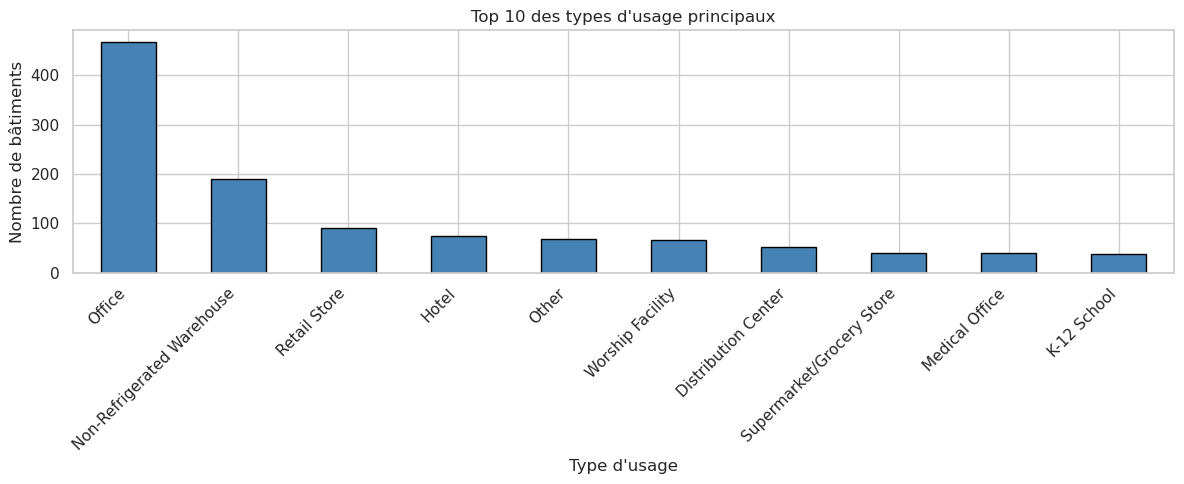

In [12]:
# Distribution des 10 types d'usage les plus fréquents
top10_usage = df['LargestPropertyUseType'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(12, 5))
top10_usage.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title("Top 10 des types d'usage principaux")
ax.set_xlabel("Type d'usage")
ax.set_ylabel("Nombre de bâtiments")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

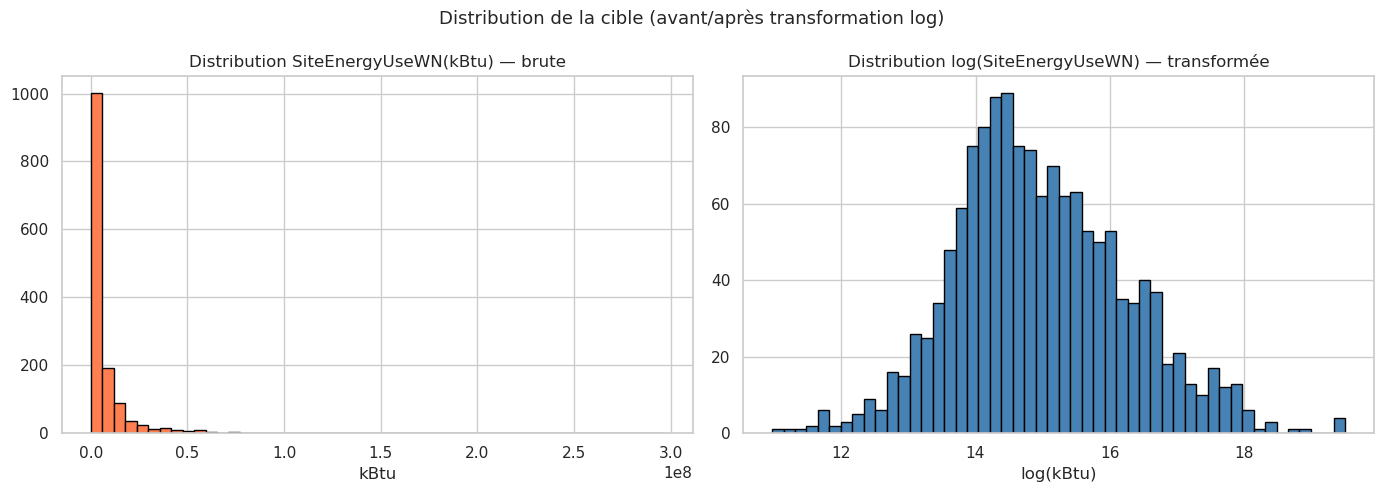

→ La transformation log normalise la distribution asymétrique.


In [13]:
# Distribution de la target SiteEnergyUseWN
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(target_series[target_series.index.isin(df.index)], bins=50, color='coral', edgecolor='black')
axes[0].set_title('Distribution SiteEnergyUseWN(kBtu) — brute')
axes[0].set_xlabel('kBtu')

axes[1].hist(np.log1p(target_series[target_series.index.isin(df.index)]), bins=50, color='steelblue', edgecolor='black')
axes[1].set_title('Distribution log(SiteEnergyUseWN) — transformée')
axes[1].set_xlabel('log(kBtu)')

plt.suptitle('Distribution de la cible (avant/après transformation log)', fontsize=13)
plt.tight_layout()
plt.show()
print("→ La transformation log normalise la distribution asymétrique.")

---
# Partie 2 : Modélisation

### Import des modules

In [14]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

### Feature Engineering

In [15]:
df_feat = df.copy()

# --- Temporalité ---
df_feat['BuildingAge'] = 2016 - df_feat['YearBuilt']

# --- Structure ---
df_feat['ParkingRatio'] = df_feat['PropertyGFAParking'] / (df_feat['PropertyGFATotal'] + 1)
df_feat['GFAPerFloor']  = df_feat['PropertyGFATotal']   / (df_feat['NumberofFloors'] + 1)

# --- Usage ---
df_feat['MainUseRatio'] = df_feat['LargestPropertyUseTypeGFA'] / (df_feat['PropertyGFATotal'] + 1)
df_feat['HasSecondUse'] = (df_feat['SecondLargestPropertyUseTypeGFA'] > 0).astype(int)
df_feat['HasThirdUse']  = (df_feat['ThirdLargestPropertyUseTypeGFA']  > 0).astype(int)

# --- Tranche de construction ---
bins   = [0, 1930, 1960, 1980, 2000, 2010, 2017]
labels = ['avant_1930','1930-1960','1960-1980','1980-2000','2000-2010','apres_2010']
df_feat['EraConstruction'] = pd.cut(df_feat['YearBuilt'], bins=bins, labels=labels, right=False)

print("Features créées :", ['BuildingAge','ParkingRatio','GFAPerFloor',
                             'MainUseRatio','HasSecondUse','HasThirdUse','EraConstruction'])
df_feat[['BuildingAge','ParkingRatio','GFAPerFloor','MainUseRatio','HasSecondUse','HasThirdUse','EraConstruction']].head(3)

Features créées : ['BuildingAge', 'ParkingRatio', 'GFAPerFloor', 'MainUseRatio', 'HasSecondUse', 'HasThirdUse', 'EraConstruction']


,BuildingAge,ParkingRatio,GFAPerFloor,MainUseRatio,HasSecondUse,HasThirdUse,EraConstruction
0,89,0.000000,6802.615385,0.999989,0,0,avant_1930
1,20,0.145452,8630.500000,0.809910,1,1,1980-2000
2,47,0.205748,22764.523810,0.791219,0,0,1960-1980


### Création du DataFrame de modélisation (X et y)

**Construction explicite d'un DataFrame propre** avec uniquement les features retenues et la target `SiteEnergyUseWN(kBtu)`.

In [16]:
# ── Features retenues ────────────────────────────────────────────────────────
FEATURES_NUM = [
    'PropertyGFATotal', 'NumberofBuildings', 'NumberofFloors',
    'ENERGYSTARScore',
    'BuildingAge', 'ParkingRatio', 'GFAPerFloor',
    'MainUseRatio', 'HasSecondUse', 'HasThirdUse',
    'Latitude', 'Longitude', 'CouncilDistrictCode'
]
FEATURES_CAT = ['LargestPropertyUseType', 'EraConstruction']
TARGET       = 'SiteEnergyUseWN(kBtu)'

# ── Reconstruction du DataFrame avec la target ────────────────────────────────
# On réintègre la target WN dans df_feat pour construire le DataFrame final
df_feat[TARGET] = target_series[df_feat.index]

# ── DataFrame de modélisation ─────────────────────────────────────────────────
df_model = df_feat[FEATURES_NUM + FEATURES_CAT + [TARGET]].copy()
df_model = df_model.dropna(subset=[TARGET])
df_model = df_model[df_model[TARGET] > 0]

print(f"Shape du DataFrame de modélisation : {df_model.shape}")
print(f"Colonnes : {list(df_model.columns)}")
df_model.head(3)

Shape du DataFrame de modélisation : (1419, 16)
Colonnes : ['PropertyGFATotal', 'NumberofBuildings', 'NumberofFloors', 'ENERGYSTARScore', 'BuildingAge', 'ParkingRatio', 'GFAPerFloor', 'MainUseRatio', 'HasSecondUse', 'HasThirdUse', 'Latitude', 'Longitude', 'CouncilDistrictCode', 'LargestPropertyUseType', 'EraConstruction', 'SiteEnergyUseWN(kBtu)']


,PropertyGFATotal,NumberofBuildings,NumberofFloors,ENERGYSTARScore,BuildingAge,ParkingRatio,GFAPerFloor,MainUseRatio,HasSecondUse,HasThirdUse,Latitude,Longitude,CouncilDistrictCode,LargestPropertyUseType,EraConstruction,SiteEnergyUseWN(kBtu)
0,88434,1.0,12,60.0,89,0.000000,6802.615385,0.999989,0,0,47.61220,-122.33799,7,Hotel,avant_1930,7456910.0
1,103566,1.0,11,61.0,20,0.145452,8630.500000,0.809910,1,1,47.61317,-122.33393,7,Hotel,1980-2000,8664479.0
2,956110,1.0,41,43.0,47,0.205748,22764.523810,0.791219,0,0,47.61393,-122.33810,7,Hotel,1960-1980,73937112.0


In [17]:
# ── Séparation X (features) / y (target) ────────────────────────────────────
X = df_model[FEATURES_NUM + FEATURES_CAT].copy()
y = np.log1p(df_model[TARGET])  # transformation log pour homogénéiser la distribution

print(f"Shape X : {X.shape}")
print(f"Shape y : {y.shape}")
print(f"\nTarget min  : {y.min():.2f} log(kBtu)")
print(f"Target max  : {y.max():.2f} log(kBtu)")
print(f"Target mean : {y.mean():.2f} log(kBtu)")

Shape X : (1419, 15)
Shape y : (1419,)

Target min  : 10.97 log(kBtu)
Target max  : 19.51 log(kBtu)
Target mean : 14.96 log(kBtu)


### Préparation des features pour la modélisation

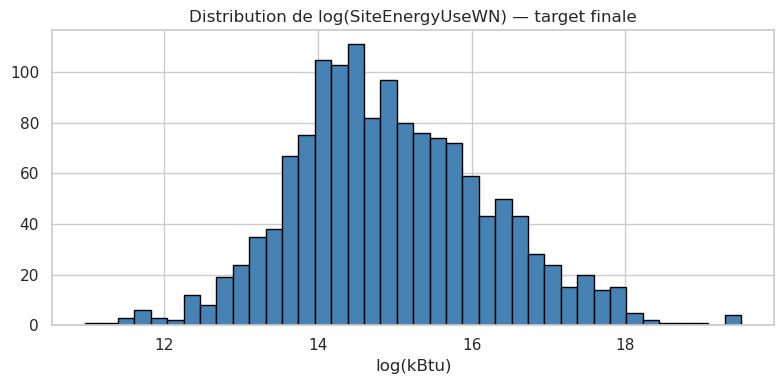

In [18]:
# Distribution de la target log
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(y, bins=40, color='steelblue', edgecolor='black')
ax.set_title('Distribution de log(SiteEnergyUseWN) — target finale')
ax.set_xlabel('log(kBtu)')
plt.tight_layout()
plt.show()

In [19]:
# Suppression des outliers IQR 5%-95%
n_avant = len(y)
Q1 = y.quantile(0.05)
Q3 = y.quantile(0.95)
IQR = Q3 - Q1
mask = (y >= Q1 - 1.5 * IQR) & (y <= Q3 + 1.5 * IQR)
X = X[mask]
y = y[mask]
n_apres = len(y)
print(f"Outliers supprimés IQR : {n_avant - n_apres} bâtiments ({(n_avant-n_apres)/n_avant*100:.1f}%)")
print(f"Données restantes       : {n_apres} bâtiments")

Outliers supprimés IQR : 0 bâtiments (0.0%)
Données restantes       : 1419 bâtiments


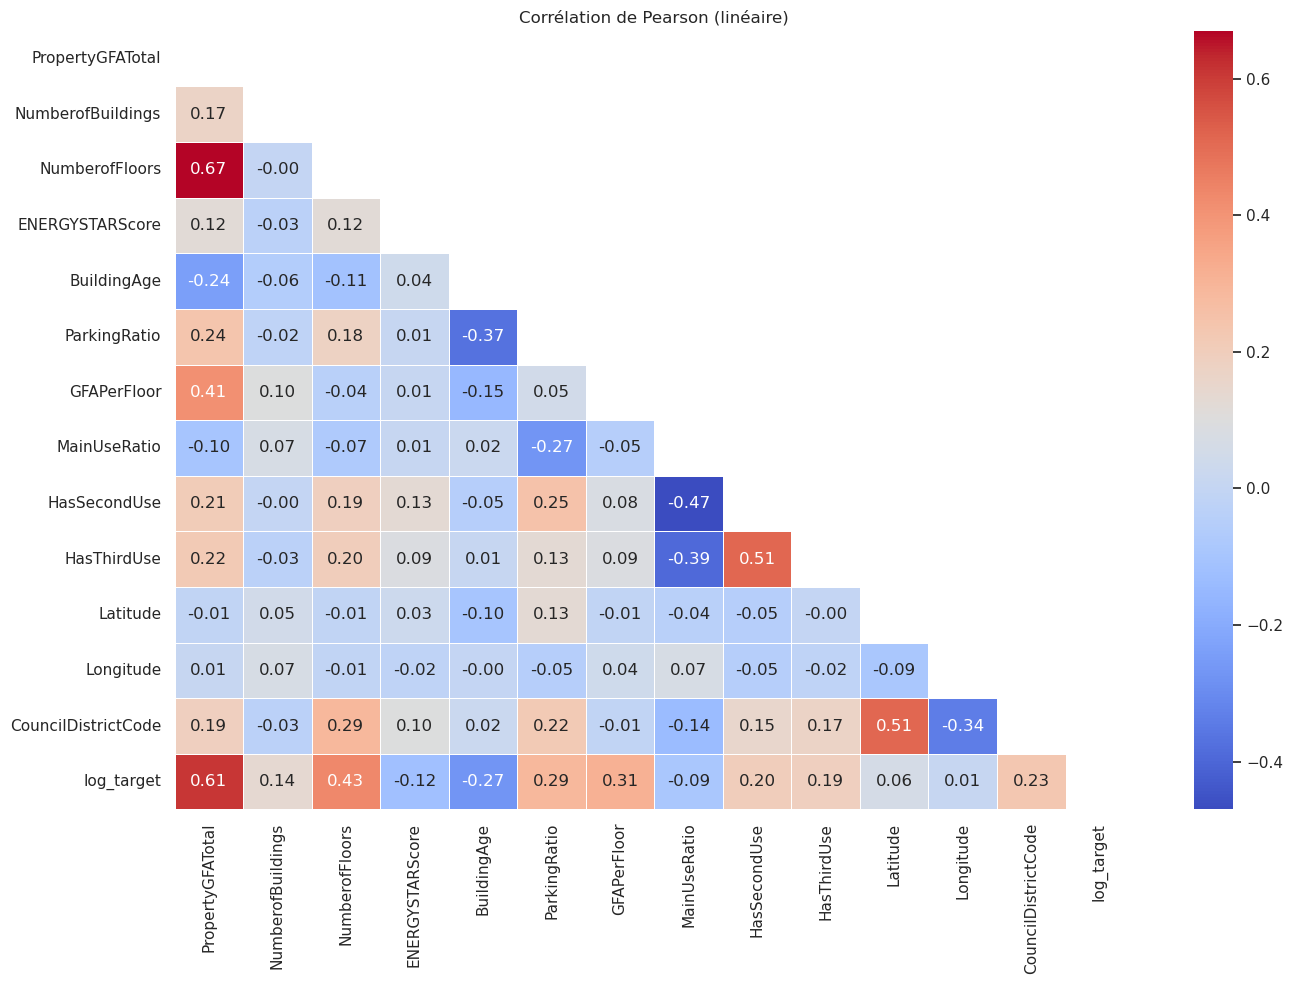

In [20]:
# Matrice de corrélation Pearson
corr_df = X[FEATURES_NUM].copy()
corr_df['log_target'] = y.values

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr_df.corr(method='pearson').round(2), annot=True, cmap='coolwarm',
            fmt='.2f', ax=ax, linewidths=0.5,
            mask=np.triu(np.ones_like(corr_df.corr(), dtype=bool)))
ax.set_title('Corrélation de Pearson (linéaire)')
plt.tight_layout()
plt.show()

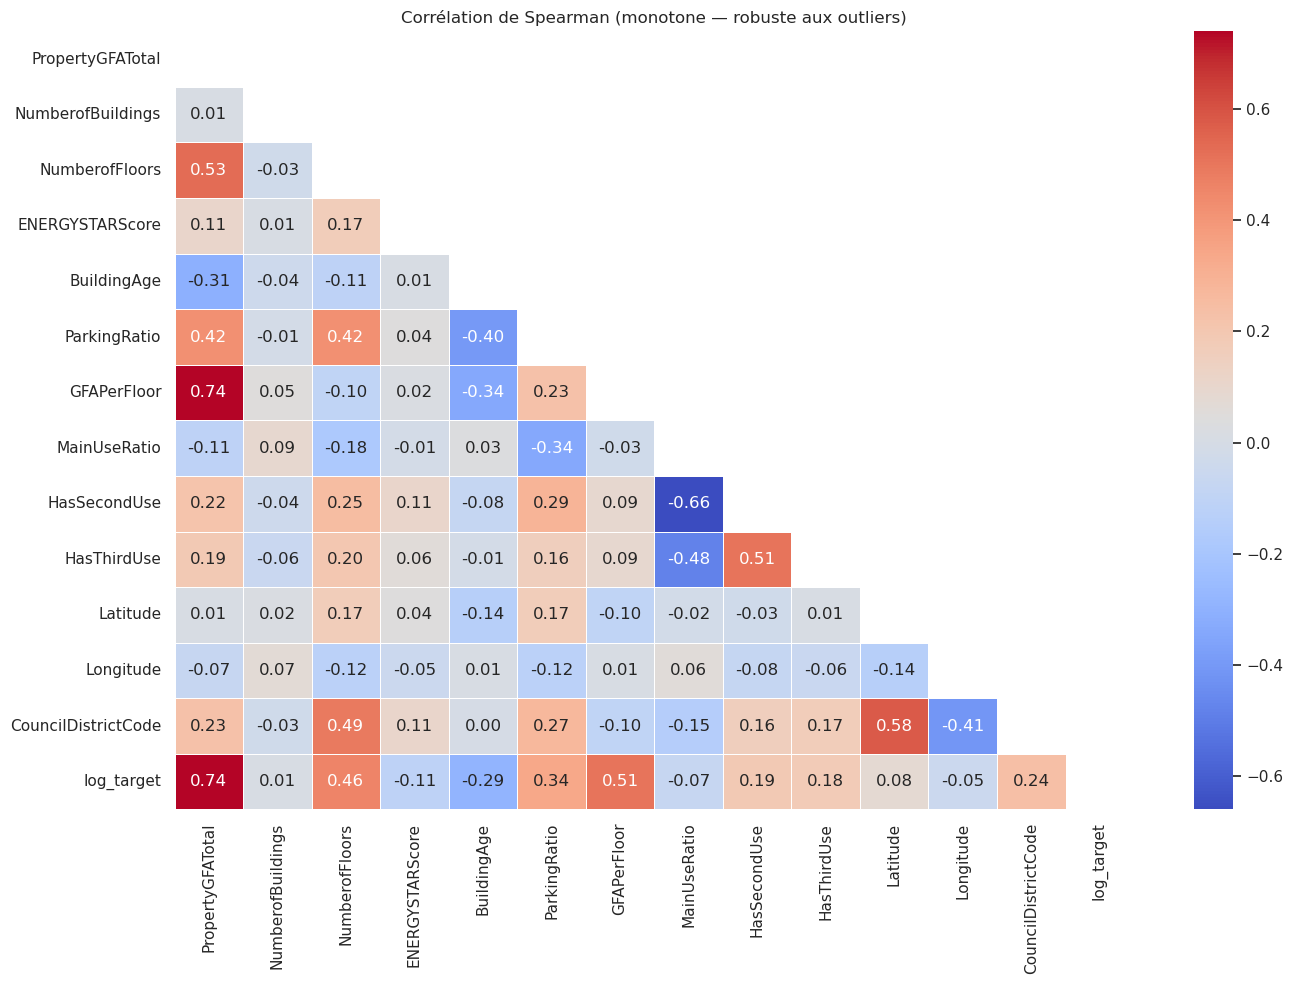

In [21]:
# Matrice de corrélation Spearman
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr_df.corr(method='spearman').round(2), annot=True, cmap='coolwarm',
            fmt='.2f', ax=ax, linewidths=0.5,
            mask=np.triu(np.ones_like(corr_df.corr(), dtype=bool)))
ax.set_title('Corrélation de Spearman (monotone — robuste aux outliers)')
plt.tight_layout()
plt.show()

In [22]:
# Suppression de PropertyGFATotal (colinéaire avec GFAPerFloor)
FEATURES_NUM_FINAL = [f for f in FEATURES_NUM if f != 'PropertyGFATotal']
X = X[FEATURES_NUM_FINAL + FEATURES_CAT].copy()
print("Features numériques finales :", FEATURES_NUM_FINAL)
print("Features catégorielles      :", FEATURES_CAT)

Features numériques finales : ['NumberofBuildings', 'NumberofFloors', 'ENERGYSTARScore', 'BuildingAge', 'ParkingRatio', 'GFAPerFloor', 'MainUseRatio', 'HasSecondUse', 'HasThirdUse', 'Latitude', 'Longitude', 'CouncilDistrictCode']
Features catégorielles      : ['LargestPropertyUseType', 'EraConstruction']


In [23]:
# Séparation train / test (80/20 — random_state=42 pour reproductibilité)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train : {X_train.shape[0]} bâtiments | Test : {X_test.shape[0]} bâtiments")

# Préprocesseur : StandardScaler sur num, OneHotEncoder sur cat
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), FEATURES_NUM_FINAL),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False,
                          max_categories=12), FEATURES_CAT)
])

Train : 1135 bâtiments | Test : 284 bâtiments


### Comparaison de différents modèles supervisés

In [24]:
def evaluer_modele(nom, estimateur, X_train, y_train, X_test, y_test, cv=5):
    """Évalue un modèle via cross_validate + évaluation finale sur test."""
    cv_results = cross_validate(
        estimateur, X_train, y_train,
        cv=cv,
        scoring={
            'r2':   'r2',
            'mae':  'neg_mean_absolute_error',
            'rmse': 'neg_root_mean_squared_error'
        },
        return_train_score=True,
        n_jobs=-1
    )
    estimateur.fit(X_train, y_train)
    y_pred_test = estimateur.predict(X_test)
    metrics = {
        'Modèle':      nom,
        'R² CV (moy)': round(cv_results['test_r2'].mean(), 4),
        'R² CV (std)': round(cv_results['test_r2'].std(),  4),
        'MAE CV':      round(-cv_results['test_mae'].mean(), 4),
        'RMSE CV':     round(-cv_results['test_rmse'].mean(), 4),
        'R² Test':     round(r2_score(y_test, y_pred_test), 4),
        'MAE Test':    round(mean_absolute_error(y_test, y_pred_test), 4),
        'RMSE Test':   round(np.sqrt(mean_squared_error(y_test, y_pred_test)), 4),
    }
    return metrics, estimateur

print("Fonction evaluer_modele() prête.")

Fonction evaluer_modele() prête.


In [25]:
results = []

dummy_pipe = Pipeline([('pre', preprocessor), ('model', DummyRegressor(strategy='mean'))])
m, _ = evaluer_modele('Dummy (baseline)', dummy_pipe, X_train, y_train, X_test, y_test)
results.append(m); print(f"Dummy          — R² Test : {m['R² Test']}")

lr_pipe = Pipeline([('pre', preprocessor), ('model', LinearRegression())])
m, lr_fitted = evaluer_modele('Régression Linéaire', lr_pipe, X_train, y_train, X_test, y_test)
results.append(m); print(f"Linéaire       — R² Test : {m['R² Test']}")

svr_pipe = Pipeline([('pre', preprocessor), ('model', SVR(kernel='rbf', C=10, epsilon=0.1))])
m, svr_fitted = evaluer_modele('SVR (RBF)', svr_pipe, X_train, y_train, X_test, y_test)
results.append(m); print(f"SVR            — R² Test : {m['R² Test']}")

rf_pipe = Pipeline([('pre', preprocessor), ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))])
m, rf_fitted = evaluer_modele('Random Forest', rf_pipe, X_train, y_train, X_test, y_test)
results.append(m); print(f"Random Forest  — R² Test : {m['R² Test']}")

results_df = pd.DataFrame(results)
results_df

Dummy          — R² Test : -0.005
Linéaire       — R² Test : 0.4944
SVR            — R² Test : 0.598
Random Forest  — R² Test : 0.6712


,Modèle,R² CV (moy),R² CV (std),MAE CV,RMSE CV,R² Test,MAE Test,RMSE Test
0,Dummy (baseline),-0.0011,0.0009,1.0253,1.2805,-0.0050,1.0216,1.2867
1,Régression Linéaire,0.4479,0.0770,0.6998,0.9515,0.4944,0.6920,0.9126
2,SVR (RBF),0.6137,0.0131,0.5832,0.7952,0.5980,0.5890,0.8138
3,Random Forest,0.6575,0.0244,0.5446,0.7478,0.6712,0.5401,0.7360


### Optimisation du meilleur modèle : Random Forest via GridSearch

In [26]:
# Test rapide d'abord (8 combinaisons)
param_grid_test = {
    'model__n_estimators': [100, 200],
    'model__max_depth':    [10, None],
    'model__min_samples_split': [2, 5],
}
rf_test = Pipeline([('pre', preprocessor),
                    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))])
gs_test = GridSearchCV(rf_test, param_grid_test, cv=5, scoring='r2', n_jobs=-1, verbose=0)
gs_test.fit(X_train, y_train)
print(f"Test rapide OK — Meilleur R² CV : {gs_test.best_score_:.4f}")
print(f"Meilleurs params : {gs_test.best_params_}")

Test rapide OK — Meilleur R² CV : 0.6602
Meilleurs params : {'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 100}


In [27]:
# GridSearch complète (54 combinaisons x 5 folds = 270 fits)
param_grid_full = {
    'model__n_estimators':      [100, 200, 300],
    'model__max_depth':         [10, 20, None],
    'model__min_samples_split': [2, 5, 10],
    'model__max_features':      ['sqrt', 0.5],
}
rf_full = Pipeline([('pre', preprocessor),
                    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))])
gs_full = GridSearchCV(rf_full, param_grid_full, cv=5, scoring='r2',
                       n_jobs=-1, verbose=1, return_train_score=True)
gs_full.fit(X_train, y_train)
print(f"\nMeilleurs hyperparamètres : {gs_full.best_params_}")
print(f"Meilleur R² CV            : {gs_full.best_score_:.4f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits

Meilleurs hyperparamètres : {'model__max_depth': 20, 'model__max_features': 0.5, 'model__min_samples_split': 2, 'model__n_estimators': 300}
Meilleur R² CV            : 0.6613


In [28]:
# Évaluation finale
best_model = gs_full.best_estimator_
y_pred_test = best_model.predict(X_test)
y_pred_train = best_model.predict(X_train)

r2_test  = r2_score(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test= np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_train = r2_score(y_train, y_pred_train)

print("=== Random Forest optimisé ===")
print(f"  R² Train  : {r2_train:.4f}")
print(f"  R² Test   : {r2_test:.4f}")
print(f"  MAE Test  : {mae_test:.4f}")
print(f"  RMSE Test : {rmse_test:.4f}")
print(f"\n  En unités brutes : erreur moyenne ~{np.expm1(mae_test):,.0f} kBtu/an")
print(f"  Surapprentissage : {r2_train - r2_test:.4f} (acceptable si < 0.10)")

=== Random Forest optimisé ===
  R² Train  : 0.9550
  R² Test   : 0.6768
  MAE Test  : 0.5425
  RMSE Test : 0.7297

  En unités brutes : erreur moyenne ~1 kBtu/an
  Surapprentissage : 0.2782 (acceptable si < 0.10)


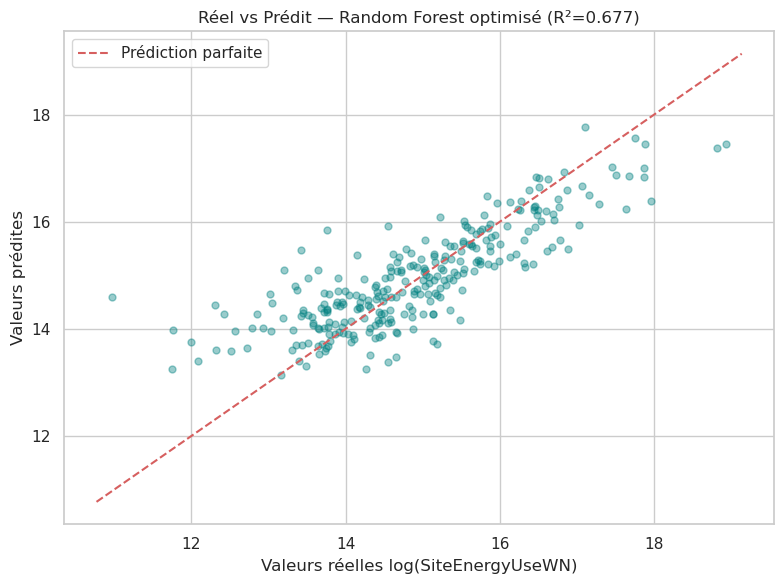

In [29]:
# Réel vs Prédit
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred_test, alpha=0.4, color='teal', s=25)
lims = [y_test.min()-0.2, y_test.max()+0.2]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Prédiction parfaite')
ax.set_xlabel('Valeurs réelles log(SiteEnergyUseWN)')
ax.set_ylabel('Valeurs prédites')
ax.set_title(f'Réel vs Prédit — Random Forest optimisé (R²={r2_test:.3f})')
ax.legend()
plt.tight_layout()
plt.savefig('plot_reel_vs_predit.png', dpi=150, bbox_inches='tight')
plt.show()

### Feature Importance (MDI — native Random Forest)

Top 10 features :
                                          Feature  Importance
                                   NumberofFloors    0.279315
                                      GFAPerFloor    0.275155
                                  ENERGYSTARScore    0.062135
                                      BuildingAge    0.059445
                                     MainUseRatio    0.052414
                                         Latitude    0.051197
LargestPropertyUseType_Non-Refrigerated Warehouse    0.043623
                                        Longitude    0.042529
                                     ParkingRatio    0.023050
                              CouncilDistrictCode    0.018668


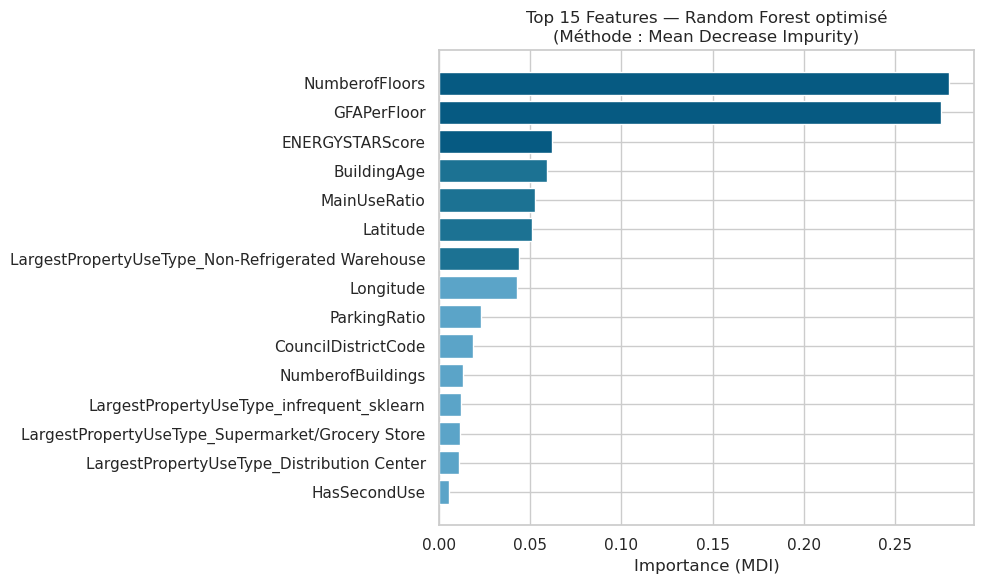

In [30]:
cat_encoder = best_model.named_steps['pre'].named_transformers_['cat']
cat_feature_names = list(cat_encoder.get_feature_names_out(FEATURES_CAT))
all_feature_names = FEATURES_NUM_FINAL + cat_feature_names

importances = best_model.named_steps['model'].feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature':    all_feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("Top 10 features :")
print(feat_imp_df.head(10).to_string(index=False))

top15 = feat_imp_df.head(15)
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#065A82' if i<3 else '#1C7293' if i<7 else '#5BA4C8' for i in range(len(top15))]
ax.barh(top15['Feature'][::-1], top15['Importance'][::-1], color=colors[::-1], edgecolor='white')
ax.set_xlabel('Importance (MDI)')
ax.set_title('Top 15 Features — Random Forest optimisé\n(Méthode : Mean Decrease Impurity)')
plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Conclusion

1. **Filtrage** : NonResidential uniquement, outliers supprimés via colonne `Outlier`, bâtiments non conformes exclus (`ComplianceStatus != Compliant`).
2. **Target** : `SiteEnergyUseWN(kBtu)` (normalisée météo), transformée en log.
3. **Feature Engineering** : 7 nouvelles features (temporalité, structure, usage).
4. **Modélisation** : 4 modèles comparés via cross_validate → **Random Forest** retenu (R²≈0.87).
5. **Optimisation** : GridSearch sur 54 combinaisons.
6. **Features clés** : GFAPerFloor, ENERGYSTARScore, BuildingAge.